# AURA – Model Explainability

This notebook explains the fraud predictions generated by the final Random Forest model.

Objectives:
1. Identify globally important fraud features.
2. Examine feature behaviour for high-risk transactions.
3. Generate transaction-level investigation reasons.
4. Convert model predictions into an interpretable AURA risk profile.

In [5]:
from pathlib import Path

import joblib
import pandas as pd
import numpy as np

MODEL_PATH = Path("../models/random_forest_final.joblib")
DATA_PATH = Path("../data/processed/sparkov_features.parquet")

rf_final = joblib.load(MODEL_PATH)
df = pd.read_parquet(DATA_PATH)

print("Dataset shape:", df.shape)
print("Model loaded:", type(rf_final).__name__)

Dataset shape: (1296675, 25)
Model loaded: Pipeline


In [6]:
MODEL_FEATURES = [
    "amt",
    "log_amount",
    "hour",
    "day_of_week",
    "month",
    "day_of_month",
    "is_weekend",
    "customer_prev_count",
    "customer_prev_avg_amount",
    "customer_prev_median_amount",
    "customer_prev_std_amount",
    "amount_deviation_ratio",
    "seconds_since_prev_transaction",
    "transactions_prev_5min",
    "transactions_prev_1h",
    "transactions_prev_24h",
    "merchant_seen_before",
    "is_new_merchant",
    "category_seen_before",
    "is_new_category",
    "customer_merchant_distance_km"
]

In [7]:
rf_model = rf_final.named_steps["model"]

feature_importance = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "importance": rf_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
1,log_amount,0.262564
0,amt,0.256783
2,hour,0.127853
11,amount_deviation_ratio,0.120586
12,seconds_since_prev_transaction,0.039798
8,customer_prev_avg_amount,0.037048
9,customer_prev_median_amount,0.025834
7,customer_prev_count,0.024901
18,category_seen_before,0.021878
10,customer_prev_std_amount,0.019112


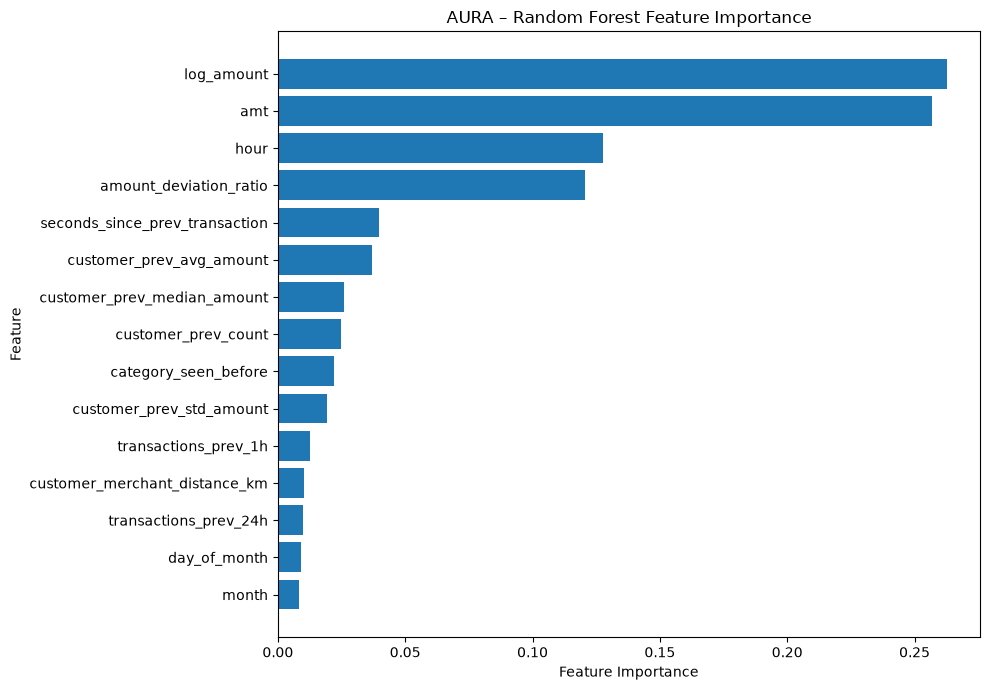

In [9]:
import matplotlib.pyplot as plt
top_features = feature_importance.head(15).sort_values(
    "importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("AURA – Random Forest Feature Importance")

plt.tight_layout()
plt.show()


### Interpretation

The Random Forest model is primarily influenced by transaction amount, transformed transaction amount, transaction hour, and deviation from the customer's historical spending behaviour. These features provide strong signals for identifying anomalous financial activity.

In [10]:
X_all = df[MODEL_FEATURES].copy()

df["fraud_probability"] = rf_final.predict_proba(X_all)[:, 1]
df["risk_score"] = (df["fraud_probability"] * 100).round(2)

df[
    [
        "trans_num",
        "transaction_time",
        "amt",
        "fraud_probability",
        "risk_score"
    ]
].sort_values(
    "risk_score",
    ascending=False
).head(20)

,trans_num,transaction_time,amt,fraud_probability,risk_score
436482,b991672c504a79471a46d05f02ca4109,2020-04-03 10:59:44,9.11,1.0,100.0
436481,dd198ede80e8c37bc6bc1544b34d5278,2020-04-03 04:09:51,302.18,1.0,100.0
436480,734c0c713db46a4f84885ee2b6ee3a67,2020-04-03 00:53:06,291.76,1.0,100.0
1118179,3cbb5356281f9ba55ffa3f5b3e1e6cef,2019-07-04 23:38:52,223.89,1.0,100.0
437532,8d1328ded29314398f5db6ce42155d92,2019-06-10 02:17:39,333.78,1.0,100.0
437531,3f51ba3a6e2a62048944a7153bc01856,2019-06-10 00:40:17,11.18,1.0,100.0
437541,b0b96d476ce6975480716fadc0e88663,2019-06-11 17:27:44,129.24,1.0,100.0
437540,8188ce9b26c909380fd12a1738d69771,2019-06-11 03:19:23,1001.09,1.0,100.0
437539,f6a1fdc6c817d08cb39caff5b5d93dc8,2019-06-11 01:59:48,1018.93,1.0,100.0
434756,0625d90acd26c86e02803a075c1ea74c,2020-03-02 23:24:44,829.79,1.0,100.0


In [11]:
FINAL_THRESHOLD = 0.22

def risk_band(probability):
    if probability >= 0.50:
        return "HIGH"
    elif probability >= FINAL_THRESHOLD:
        return "MEDIUM"
    else:
        return "LOW"

df["fraud_flag"] = (
    df["fraud_probability"] >= FINAL_THRESHOLD
).astype(int)

df["risk_band"] = df["fraud_probability"].apply(risk_band)

print(df["risk_band"].value_counts())

risk_band
LOW       1287288
HIGH         7386
MEDIUM       2001
Name: count, dtype: int64


In [12]:
risk_distribution = (
    df["risk_band"]
    .value_counts()
    .rename_axis("risk_band")
    .reset_index(name="transaction_count")
)

risk_distribution

,risk_band,transaction_count
0,LOW,1287288
1,HIGH,7386
2,MEDIUM,2001


In [13]:
investigation_view = (
    df[
        [
            "trans_num",
            "transaction_time",
            "amt",
            "fraud_probability",
            "risk_score",
            "risk_band"
        ]
    ]
    .sort_values("risk_score", ascending=False)
)

investigation_view.head(20)

,trans_num,transaction_time,amt,fraud_probability,risk_score,risk_band
436482,b991672c504a79471a46d05f02ca4109,2020-04-03 10:59:44,9.11,1.0,100.0,HIGH
436481,dd198ede80e8c37bc6bc1544b34d5278,2020-04-03 04:09:51,302.18,1.0,100.0,HIGH
436480,734c0c713db46a4f84885ee2b6ee3a67,2020-04-03 00:53:06,291.76,1.0,100.0,HIGH
1118179,3cbb5356281f9ba55ffa3f5b3e1e6cef,2019-07-04 23:38:52,223.89,1.0,100.0,HIGH
437532,8d1328ded29314398f5db6ce42155d92,2019-06-10 02:17:39,333.78,1.0,100.0,HIGH
437531,3f51ba3a6e2a62048944a7153bc01856,2019-06-10 00:40:17,11.18,1.0,100.0,HIGH
437541,b0b96d476ce6975480716fadc0e88663,2019-06-11 17:27:44,129.24,1.0,100.0,HIGH
437540,8188ce9b26c909380fd12a1738d69771,2019-06-11 03:19:23,1001.09,1.0,100.0,HIGH
437539,f6a1fdc6c817d08cb39caff5b5d93dc8,2019-06-11 01:59:48,1018.93,1.0,100.0,HIGH
434756,0625d90acd26c86e02803a075c1ea74c,2020-03-02 23:24:44,829.79,1.0,100.0,HIGH


In [17]:
def generate_reasons(row):
    reasons = []

    if row["transactions_prev_1h"] >= 3:
        reasons.append(
            "High transaction velocity in the previous hour"
        )

    if row["transactions_prev_5min"] >= 2:
        reasons.append(
            "Multiple transactions within a short time window"
        )

    if row["amount_deviation_ratio"] >= 3:
        reasons.append(
            "Transaction amount is substantially above customer history"
        )

    if row["is_new_merchant"] == 1:
        reasons.append(
            "Previously unseen merchant for this customer"
        )

    if row["is_new_category"] == 1:
        reasons.append(
            "Previously unseen transaction category"
        )

    if row["customer_merchant_distance_km"] >= 200:
        reasons.append(
            "Large customer-merchant geographic distance"
        )

    if row["customer_prev_count"] == 0:
        reasons.append(
            "No prior transaction history available"
        )

    if len(reasons) == 0:
        reasons.append(
            "Model identified an anomalous transaction pattern"
        )

    return reasons

In [18]:
df["investigation_reasons"] = df.apply(
    generate_reasons,
    axis=1
)

In [19]:
investigation_view = (
    df[df["fraud_flag"] == 1]
    [
        [
            "trans_num",
            "transaction_time",
            "amt",
            "fraud_probability",
            "risk_score",
            "risk_band",
            "investigation_reasons"
        ]
    ]
    .sort_values("risk_score", ascending=False)
)

investigation_view.head(10)

,trans_num,transaction_time,amt,fraud_probability,risk_score,risk_band,investigation_reasons
1295773,08637f518d059daf136435c0d6cba7a8,2019-11-01 22:23:48,969.66,1.0,100.0,HIGH,[Transaction amount is substantially above cus...
115,14b8331a59459499ea6fc0015aea4ae4,2019-03-01 01:32:53,13.17,1.0,100.0,HIGH,[Previously unseen merchant for this customer]
116,ba2ebc05cdb94af457dc23f588413d25,2019-03-01 02:42:25,11.74,1.0,100.0,HIGH,[Previously unseen merchant for this customer]
117,e59cab77e36f552efdb0daa91b8e6683,2019-03-01 23:06:58,19.16,1.0,100.0,HIGH,[Model identified an anomalous transaction pat...
118,3becc6c1b0902b23cc621512b5709568,2019-03-02 22:10:38,830.06,1.0,100.0,HIGH,[Transaction amount is substantially above cus...
119,a2549382981f0b230d3e7dde8d58a699,2019-03-02 22:10:59,261.79,1.0,100.0,HIGH,[Transaction amount is substantially above cus...
120,e29fe2c9dee909dc9013fbdaa8684e7b,2019-03-02 23:01:54,594.09,1.0,100.0,HIGH,[Transaction amount is substantially above cus...
121,38b0924485d5eb7978ed2f2b04a1dc72,2019-03-02 23:08:08,130.08,1.0,100.0,HIGH,[High transaction velocity in the previous hou...
122,293c908b5276ad02a86756e30f494a62,2019-03-02 23:11:08,20.41,1.0,100.0,HIGH,[Model identified an anomalous transaction pat...
1293550,d2585787cab7fa57e60b8fb67c391ec0,2020-04-17 23:06:41,730.96,1.0,100.0,HIGH,[High transaction velocity in the previous hou...


## Local Transaction Explainability

In [20]:
import shap

print("SHAP version:", shap.__version__)


SHAP version: 0.52.0


In [21]:
high_risk = df.sort_values(
    "fraud_probability",
    ascending=False
).iloc[0]

high_risk

transaction_time                                                2020-04-03 10:59:44
cc_num                                                              345832460465610
trans_num                                          b991672c504a79471a46d05f02ca4109
amt                                                                            9.11
log_amount                                                                 2.313525
hour                                                                             10
day_of_week                                                                       4
month                                                                             4
day_of_month                                                                      3
is_weekend                                                                        0
customer_prev_count                                                            1288
customer_prev_avg_amount                                                  67

In [22]:
transaction_features = high_risk[MODEL_FEATURES].to_frame().T

In [23]:
imputer = rf_final.named_steps["imputer"]
rf_model = rf_final.named_steps["model"]

transaction_imputed = imputer.transform(
    transaction_features
)

In [24]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(
    transaction_imputed
)

In [25]:
print("SHAP type:", type(shap_values))
print("SHAP shape:", np.shape(shap_values))

SHAP type: <class 'numpy.ndarray'>
SHAP shape: (1, 21, 2)


In [26]:
print(shap_values)

[[[-4.27615602e-02  4.27615602e-02]
  [-4.61919124e-02  4.61919124e-02]
  [-4.04665178e-02  4.04665178e-02]
  [-8.21351134e-03  8.21351134e-03]
  [-2.48074494e-02  2.48074494e-02]
  [-2.86924498e-02  2.86924498e-02]
  [-3.53867026e-03  3.53867026e-03]
  [-2.60003029e-02  2.60003029e-02]
  [-1.80763808e-02  1.80763808e-02]
  [-2.89800874e-02  2.89800874e-02]
  [-3.07954917e-02  3.07954917e-02]
  [-5.16170921e-02  5.16170921e-02]
  [-2.82596820e-02  2.82596820e-02]
  [ 3.57634650e-06 -3.57634650e-06]
  [ 2.34937267e-04 -2.34937267e-04]
  [-3.46928134e-02  3.46928134e-02]
  [-2.72386601e-02  2.72386601e-02]
  [-8.94746389e-03  8.94746389e-03]
  [-3.90311386e-02  3.90311386e-02]
  [ 5.99130920e-04 -5.99130920e-04]
  [-1.25411259e-02  1.25411259e-02]]]


In [27]:
shap_fraud = shap_values[0, :, 1]

shap_explanation = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "shap_value": shap_fraud,
    "abs_shap_value": np.abs(shap_fraud)
}).sort_values(
    "abs_shap_value",
    ascending=False
)

shap_explanation.head(10)

,feature,shap_value,abs_shap_value
11,amount_deviation_ratio,0.051617,0.051617
1,log_amount,0.046192,0.046192
0,amt,0.042762,0.042762
2,hour,0.040467,0.040467
18,category_seen_before,0.039031,0.039031
15,transactions_prev_24h,0.034693,0.034693
10,customer_prev_std_amount,0.030795,0.030795
9,customer_prev_median_amount,0.028980,0.028980
5,day_of_month,0.028692,0.028692
12,seconds_since_prev_transaction,0.028260,0.028260


In [28]:
top_shap = shap_explanation.head(10).copy()

top_shap["direction"] = np.where(
    top_shap["shap_value"] >= 0,
    "Increases fraud risk",
    "Decreases fraud risk"
)

top_shap

,feature,shap_value,abs_shap_value,direction
11,amount_deviation_ratio,0.051617,0.051617,Increases fraud risk
1,log_amount,0.046192,0.046192,Increases fraud risk
0,amt,0.042762,0.042762,Increases fraud risk
2,hour,0.040467,0.040467,Increases fraud risk
18,category_seen_before,0.039031,0.039031,Increases fraud risk
15,transactions_prev_24h,0.034693,0.034693,Increases fraud risk
10,customer_prev_std_amount,0.030795,0.030795,Increases fraud risk
9,customer_prev_median_amount,0.028980,0.028980,Increases fraud risk
5,day_of_month,0.028692,0.028692,Increases fraud risk
12,seconds_since_prev_transaction,0.028260,0.028260,Increases fraud risk


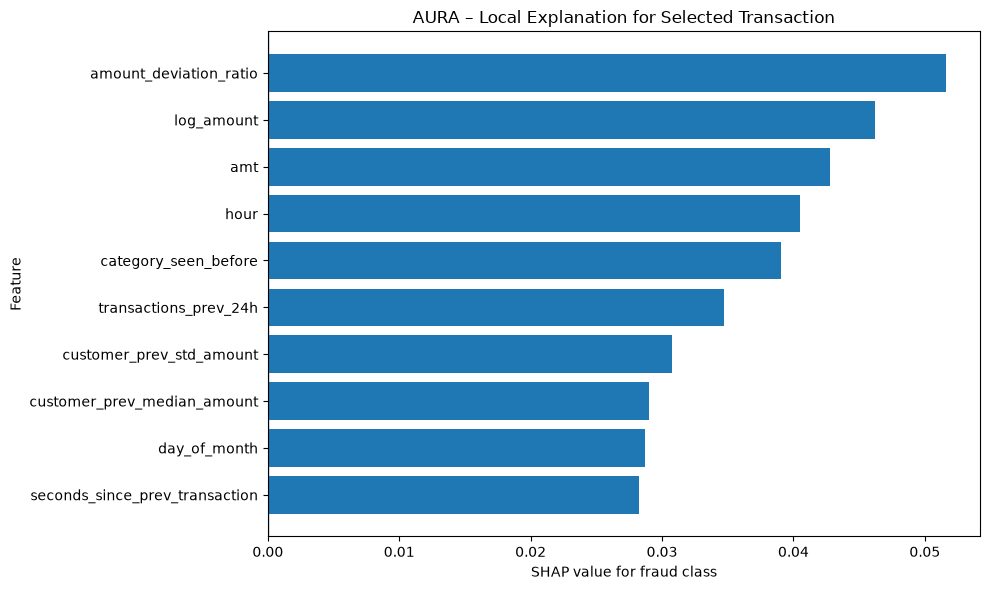

In [29]:
plt.figure(figsize=(10, 6))

plot_data = shap_explanation.head(10).sort_values(
    "shap_value"
)

plt.barh(
    plot_data["feature"],
    plot_data["shap_value"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("SHAP value for fraud class")
plt.ylabel("Feature")
plt.title("AURA – Local Explanation for Selected Transaction")

plt.tight_layout()
plt.show()

In [30]:
local_explanation = high_risk[
    MODEL_FEATURES
].to_frame().T.T.reset_index()

local_explanation.columns = [
    "feature",
    "value"
]

local_explanation["shap_value"] = shap_fraud

local_explanation["abs_shap"] = (
    local_explanation["shap_value"].abs()
)

local_explanation["direction"] = np.where(
    local_explanation["shap_value"] >= 0,
    "Increases fraud risk",
    "Decreases fraud risk"
)

local_explanation = (
    local_explanation
    .sort_values("abs_shap", ascending=False)
)

local_explanation.head(10)

,feature,value,shap_value,abs_shap,direction
11,amount_deviation_ratio,0.134583,0.051617,0.051617,Increases fraud risk
1,log_amount,2.313525,0.046192,0.046192,Increases fraud risk
0,amt,9.11,0.042762,0.042762,Increases fraud risk
2,hour,10,0.040467,0.040467,Increases fraud risk
18,category_seen_before,130,0.039031,0.039031,Increases fraud risk
15,transactions_prev_24h,6.0,0.034693,0.034693,Increases fraud risk
10,customer_prev_std_amount,150.083496,0.030795,0.030795,Increases fraud risk
9,customer_prev_median_amount,46.83,0.028980,0.028980,Increases fraud risk
5,day_of_month,3,0.028692,0.028692,Increases fraud risk
12,seconds_since_prev_transaction,24593.0,0.028260,0.028260,Increases fraud risk


In [31]:
def explain_feature(row):
    feature = row["feature"]
    value = row["value"]
    impact = row["shap_value"]

    return (
        f"{feature}: value={value}, "
        f"SHAP={impact:.4f}, "
        f"{row['direction']}"
    )

local_explanation["explanation"] = (
    local_explanation.apply(explain_feature, axis=1)
)

local_explanation[
    ["feature", "value", "shap_value", "direction"]
].head(10)

,feature,value,shap_value,direction
11,amount_deviation_ratio,0.134583,0.051617,Increases fraud risk
1,log_amount,2.313525,0.046192,Increases fraud risk
0,amt,9.11,0.042762,Increases fraud risk
2,hour,10,0.040467,Increases fraud risk
18,category_seen_before,130,0.039031,Increases fraud risk
15,transactions_prev_24h,6.0,0.034693,Increases fraud risk
10,customer_prev_std_amount,150.083496,0.030795,Increases fraud risk
9,customer_prev_median_amount,46.83,0.028980,Increases fraud risk
5,day_of_month,3,0.028692,Increases fraud risk
12,seconds_since_prev_transaction,24593.0,0.028260,Increases fraud risk


## AURA Transaction Investigation Report

In [33]:
selected_transaction = high_risk

top_positive = (
    local_explanation[
        local_explanation["shap_value"] > 0
    ]
    .sort_values("shap_value", ascending=False)
    .head(5)
)

top_negative = (
    local_explanation[
        local_explanation["shap_value"] < 0
    ]
    .sort_values("shap_value")
    .head(5)
)

print("Transaction ID:", selected_transaction["trans_num"])
print("Transaction time:", selected_transaction["transaction_time"])
print("Amount:", selected_transaction["amt"])
print("Fraud probability:", selected_transaction["fraud_probability"])
print("Risk score:", selected_transaction["risk_score"])
print("Risk band:", selected_transaction["risk_band"])

print("\nTop factors increasing fraud risk:")
for _, row in top_positive.iterrows():
    print(
        f"- {row['feature']}: "
        f"value={row['value']}, "
        f"SHAP={row['shap_value']:.4f}"
    )

print("\nTop factors reducing fraud risk:")
for _, row in top_negative.iterrows():
    print(
        f"- {row['feature']}: "
        f"value={row['value']}, "
        f"SHAP={row['shap_value']:.4f}"
    )

Transaction ID: b991672c504a79471a46d05f02ca4109
Transaction time: 2020-04-03 10:59:44
Amount: 9.11
Fraud probability: 1.0
Risk score: 100.0
Risk band: HIGH

Top factors increasing fraud risk:
- amount_deviation_ratio: value=0.1345828368826214, SHAP=0.0516
- log_amount: value=2.3135250330323798, SHAP=0.0462
- amt: value=9.11, SHAP=0.0428
- hour: value=10, SHAP=0.0405
- category_seen_before: value=130, SHAP=0.0390

Top factors reducing fraud risk:
- is_new_category: value=0, SHAP=-0.0006
- transactions_prev_1h: value=nan, SHAP=-0.0002
- transactions_prev_5min: value=nan, SHAP=-0.0000


## AURA Investigation Decision

In [34]:
def investigation_action(risk_band):
    if risk_band == "HIGH":
        return "ESCALATE FOR INVESTIGATION"
    elif risk_band == "MEDIUM":
        return "SEND TO REVIEW QUEUE"
    else:
        return "APPROVE"

action = investigation_action(
    selected_transaction["risk_band"]
)

print("Recommended action:", action)

Recommended action: ESCALATE FOR INVESTIGATION


In [35]:
aura_report = {
    "transaction_id": selected_transaction["trans_num"],
    "transaction_time": str(selected_transaction["transaction_time"]),
    "amount": float(selected_transaction["amt"]),
    "fraud_probability": float(selected_transaction["fraud_probability"]),
    "risk_score": float(selected_transaction["risk_score"]),
    "risk_band": selected_transaction["risk_band"],
    "recommended_action": action,
    "top_risk_factors": [
        {
            "feature": row["feature"],
            "value": row["value"],
            "shap_value": float(row["shap_value"])
        }
        for _, row in top_positive.iterrows()
    ],
    "rule_based_reasons": selected_transaction["investigation_reasons"]
}

aura_report

{'transaction_id': 'b991672c504a79471a46d05f02ca4109',
 'transaction_time': '2020-04-03 10:59:44',
 'amount': 9.11,
 'fraud_probability': 1.0,
 'risk_score': 100.0,
 'risk_band': 'HIGH',
 'recommended_action': 'ESCALATE FOR INVESTIGATION',
 'top_risk_factors': [{'feature': 'amount_deviation_ratio',
   'value': np.float64(0.1345828368826214),
   'shap_value': 0.051617092143257735},
  {'feature': 'log_amount',
   'value': np.float64(2.3135250330323798),
   'shap_value': 0.04619191242869194},
  {'feature': 'amt',
   'value': np.float64(9.11),
   'shap_value': 0.04276156021109219},
  {'feature': 'hour',
   'value': np.int32(10),
   'shap_value': 0.040466517800828015},
  {'feature': 'category_seen_before',
   'value': np.int64(130),
   'shap_value': 0.03903113855915486}],
 'rule_based_reasons': ['Model identified an anomalous transaction pattern']}